<a href="https://colab.research.google.com/github/jessrat/MachineLearnin_unidad1/blob/main/Unidad1_MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# leo archivo CSV desde una carpeta local

import io
import pandas as pd
from google.colab import files
uploaded = files.upload()







Saving S2_DATASET_TAREA_SET_A_INTAA1301.csv to S2_DATASET_TAREA_SET_A_INTAA1301.csv


In [ ]:
import pandas as pd

# carga de dataset y primera revisión de columnas y tipos de datos

df = pd.read_csv("S2_DATASET_TAREA_SET_A_INTAA1301.csv")

print(df.head())
print(df.info())

   anio      mes   producto  produccion_unidades  costo_usd  planta  turno
0  2025    Abril  carton a                1166.0       5901     Sur   dia 
1  2023    Enero  carton a                 943.0       6048  norte    dia 
2  2025    Junio   CARTON B                868.0       4050     Sur  NOCHE
3  2025    Enero  carton a                 898.0       4684   Norte    Dia
4  2023  Febrero  carton a                1195.0       4716     Sur  NOCHE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   anio                 200 non-null    int64  
 1   mes                  200 non-null    object 
 2   producto             200 non-null    object 
 3   produccion_unidades  199 non-null    float64
 4   costo_usd            200 non-null    int64  
 5   planta               200 non-null    object 
 6   turno                200 non-null    obje

In [ ]:
# valores nulos
print(df.isnull().sum())

df["produccion_unidades"] = df["produccion_unidades"].fillna(df["produccion_unidades"].median())

anio                   0
mes                    0
producto               0
produccion_unidades    1
costo_usd              0
planta                 0
turno                  0
dtype: int64


In [ ]:
# busco registros duplicados

print(df.duplicated().sum())

0


In [ ]:
# Las columnas producto, planta y turno tiene mayusculas y minusculas
# se estandarizan los nombres a mayusculas

df["producto"] = df["producto"].str.strip().str.upper()
df["planta"] = df["planta"].str.strip().str.upper()
df["turno"] = df["turno"].str.strip().str.upper()

print(df["producto"])
print(df["planta"])
print(df["turno"])

0      CARTON A
1      CARTON A
2      CARTON B
3      CARTON A
4      CARTON A
         ...   
195    CARTON A
196    CARTON B
197    CARTON B
198    CARTON B
199    CARTON A
Name: producto, Length: 200, dtype: object
0        SUR
1      NORTE
2        SUR
3      NORTE
4        SUR
       ...  
195      SUR
196    NORTE
197      SUR
198      SUR
199    NORTE
Name: planta, Length: 200, dtype: object
0        DIA
1        DIA
2      NOCHE
3        DIA
4      NOCHE
       ...  
195    NOCHE
196      DIA
197      DIA
198      DIA
199      DIA
Name: turno, Length: 200, dtype: object


In [ ]:
# tipos de datos

print(df.dtypes)

anio                     int64
mes                     object
producto                object
produccion_unidades    float64
costo_usd                int64
planta                  object
turno                   object
dtype: object


In [ ]:
# Busqueda de valores atipicos

Q1 = df["produccion_unidades"].quantile(0.25)

Q3 = df["produccion_unidades"].quantile(0.75)

IQR = Q3 - Q1

outliers = df[

(df["produccion_unidades"] < Q1 - 1.5 * IQR) |

(df["produccion_unidades"] > Q3 + 1.5 * IQR) ]

print(outliers)

Empty DataFrame
Columns: [anio, mes, producto, produccion_unidades, costo_usd, planta, turno]
Index: []


In [ ]:
# valores incoherentes
print(df[df["produccion_unidades"] <= 0])

print(df[df["costo_usd"] <= 0])

Empty DataFrame
Columns: [anio, mes, producto, produccion_unidades, costo_usd, planta, turno]
Index: []
Empty DataFrame
Columns: [anio, mes, producto, produccion_unidades, costo_usd, planta, turno]
Index: []


anio
2023    77863.0
2024    71714.0
2025    85384.0
Name: produccion_unidades, dtype: float64


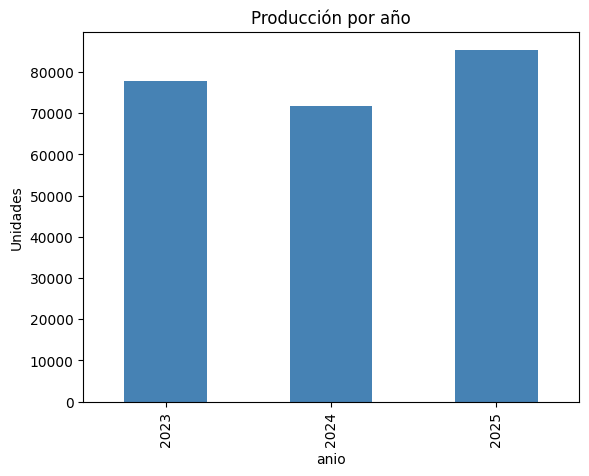

In [ ]:
# producción por año
import pandas as pd
import matplotlib.pyplot as plt

produccion_anio = df.groupby("anio")["produccion_unidades"].sum()

print(produccion_anio)

produccion_anio.plot(kind="bar", color="steelblue")
plt.title("Producción por año")
plt.ylabel("Unidades")
plt.show()

mes
Abril      38169.0
Enero      48568.0
Febrero    24394.0
Julio      23394.0
Junio      36545.0
Marzo      38801.0
Mayo       25090.0
Name: produccion_unidades, dtype: float64


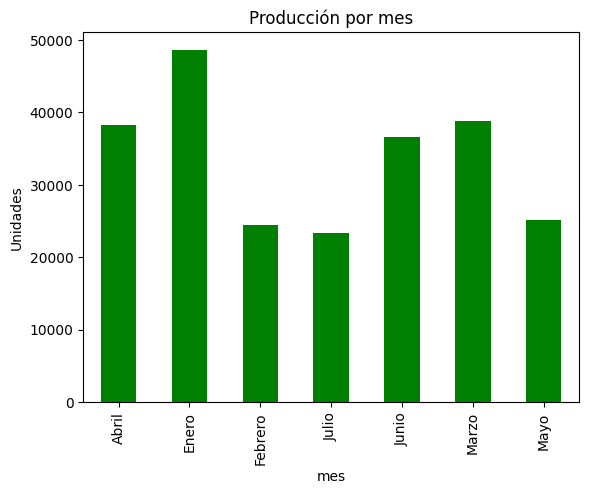

In [ ]:
# producción por mes

produccion_mes = df.groupby("mes")["produccion_unidades"].sum()
print(produccion_mes)
produccion_mes.plot(kind="bar", color="green")
plt.title("Producción por mes")
plt.ylabel("Unidades")
plt.show()

planta
NORTE    110101.0
SUR      124860.0
Name: produccion_unidades, dtype: float64


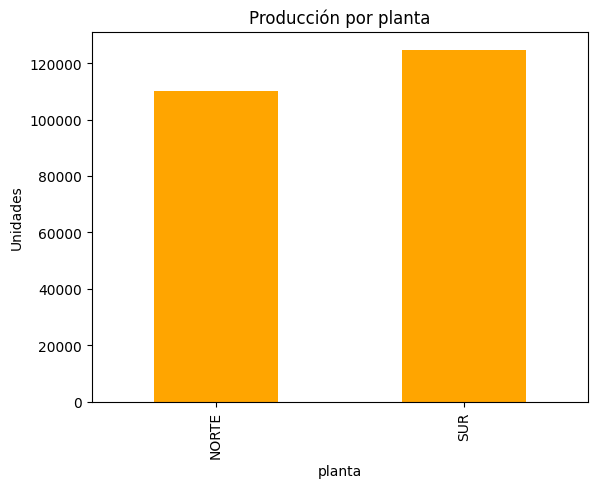

In [ ]:
# producción por planta
produccion_planta = df.groupby("planta")["produccion_unidades"].sum()
print(produccion_planta)
produccion_planta.plot(kind="bar", color="orange")
plt.title("Producción por planta")
plt.ylabel("Unidades")
plt.show()

producto
CARTON A    103539.0
CARTON B     81215.0
CARTON C     50207.0
Name: produccion_unidades, dtype: float64


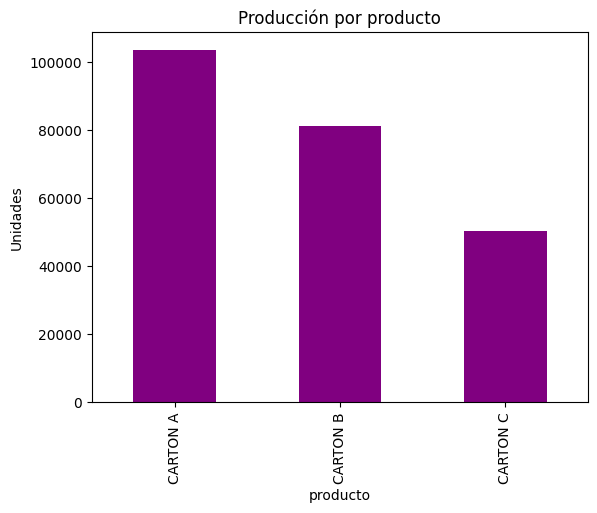

In [ ]:
produccion_producto = df.groupby("producto")["produccion_unidades"].sum()
print(produccion_producto)
produccion_producto.plot(kind="bar", color="purple")
plt.title("Producción por producto")
plt.ylabel("Unidades")
plt.show()

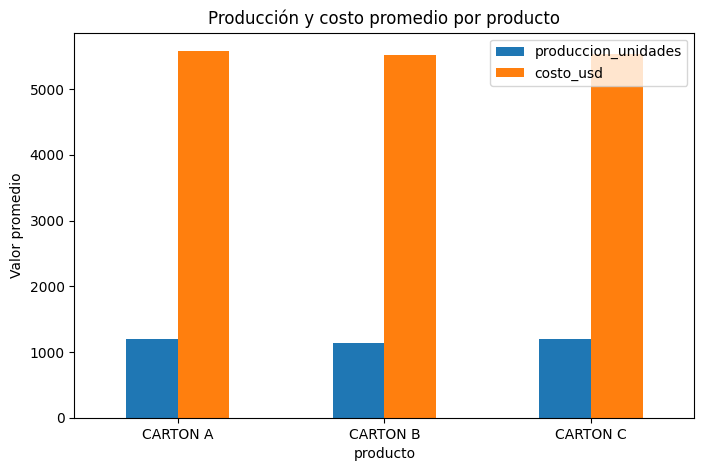

In [ ]:
resumen = df.groupby("producto").agg({
    "produccion_unidades":"mean",
    "costo_usd":"mean"
})

resumen.plot(kind="bar", figsize=(8,5))

plt.title("Producción y costo promedio por producto")
plt.ylabel("Valor promedio")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# detaccion de anomalias

estadisticas = df["produccion_unidades"].describe()

tabla = pd.DataFrame({
    "Estadística": estadisticas.index,
    "Valor": estadisticas.values
})

print(tabla)

  Estadística        Valor
0       count   200.000000
1        mean  1174.805000
2         std   233.916656
3         min   800.000000
4         25%   968.500000
5         50%  1172.000000
6         75%  1364.000000
7         max  1597.000000


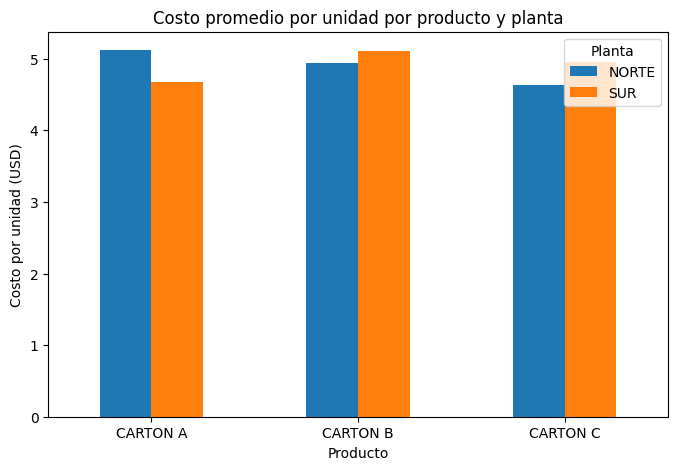

In [ ]:
df["costo_por_unidad"] = (
    df["costo_usd"] / df["produccion_unidades"]
)

tabla = df.pivot_table(
    values="costo_por_unidad",
    index="producto",
    columns="planta",
    aggfunc="mean"
)

tabla.plot(kind="bar", figsize=(8,5))

plt.title("Costo promedio por unidad por producto y planta")
plt.xlabel("Producto")
plt.ylabel("Costo por unidad (USD)")
plt.xticks(rotation=0)
plt.legend(title="Planta")
plt.show()